# Topic Models

Non-negative matrix factorization

In [2]:
import pandas as pd
df = pd.read_csv("../eda/un-general-debates-blueprint.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7507 entries, 0 to 7506
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   session       7507 non-null   int64 
 1   year          7507 non-null   int64 
 2   country       7507 non-null   object
 3   country_name  7507 non-null   object
 4   speaker       7480 non-null   object
 5   position      4502 non-null   object
 6   text          7507 non-null   object
dtypes: int64(2), object(5)
memory usage: 410.7+ KB


In [4]:
print(repr(df.iloc[0]['text'][:200]))

'33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly?\n34.\tIn taking up the work '


In [8]:
print(repr(df.iloc[3]['text'][:200]))

'155.\t  May I begin by expressing to Ambassador Hambro, on behalf of the delegation of Austria, our best wishes on his election as President of this General Assembly.\n156.\tWe derive great satisfaction '


In [17]:
import re

df['paragraphs'] = df['text'].map(lambda text:re.split(r'\.\s*\n', text))
df['number_of_paragraphs'] = df['paragraphs'].map(len)

In [34]:
df.shape

(7507, 9)

In [18]:
df.head()

,session,year,country,country_name,speaker,position,text,paragraphs,number_of_paragraphs
0,25,1970,ALB,Albania,Mr. NAS,NaN,33: May I first convey to our President the co...,[33: May I first convey to our President the c...,57
1,25,1970,ARG,Argentina,Mr. DE PABLO PARDO,NaN,177.\t : It is a fortunate coincidence that pr...,[177.\t : It is a fortunate coincidence that p...,50
2,25,1970,AUS,Australia,Mr. McMAHON,NaN,100.\t It is a pleasure for me to extend to y...,[100.\t It is a pleasure for me to extend to ...,71
3,25,1970,AUT,Austria,Mr. KIRCHSCHLAEGER,NaN,155.\t May I begin by expressing to Ambassado...,[155.\t May I begin by expressing to Ambassad...,40
4,25,1970,BEL,Belgium,Mr. HARMEL,NaN,"176. No doubt each of us, before coming up to ...","[176. No doubt each of us, before coming up to...",59


<Axes: xlabel='year'>

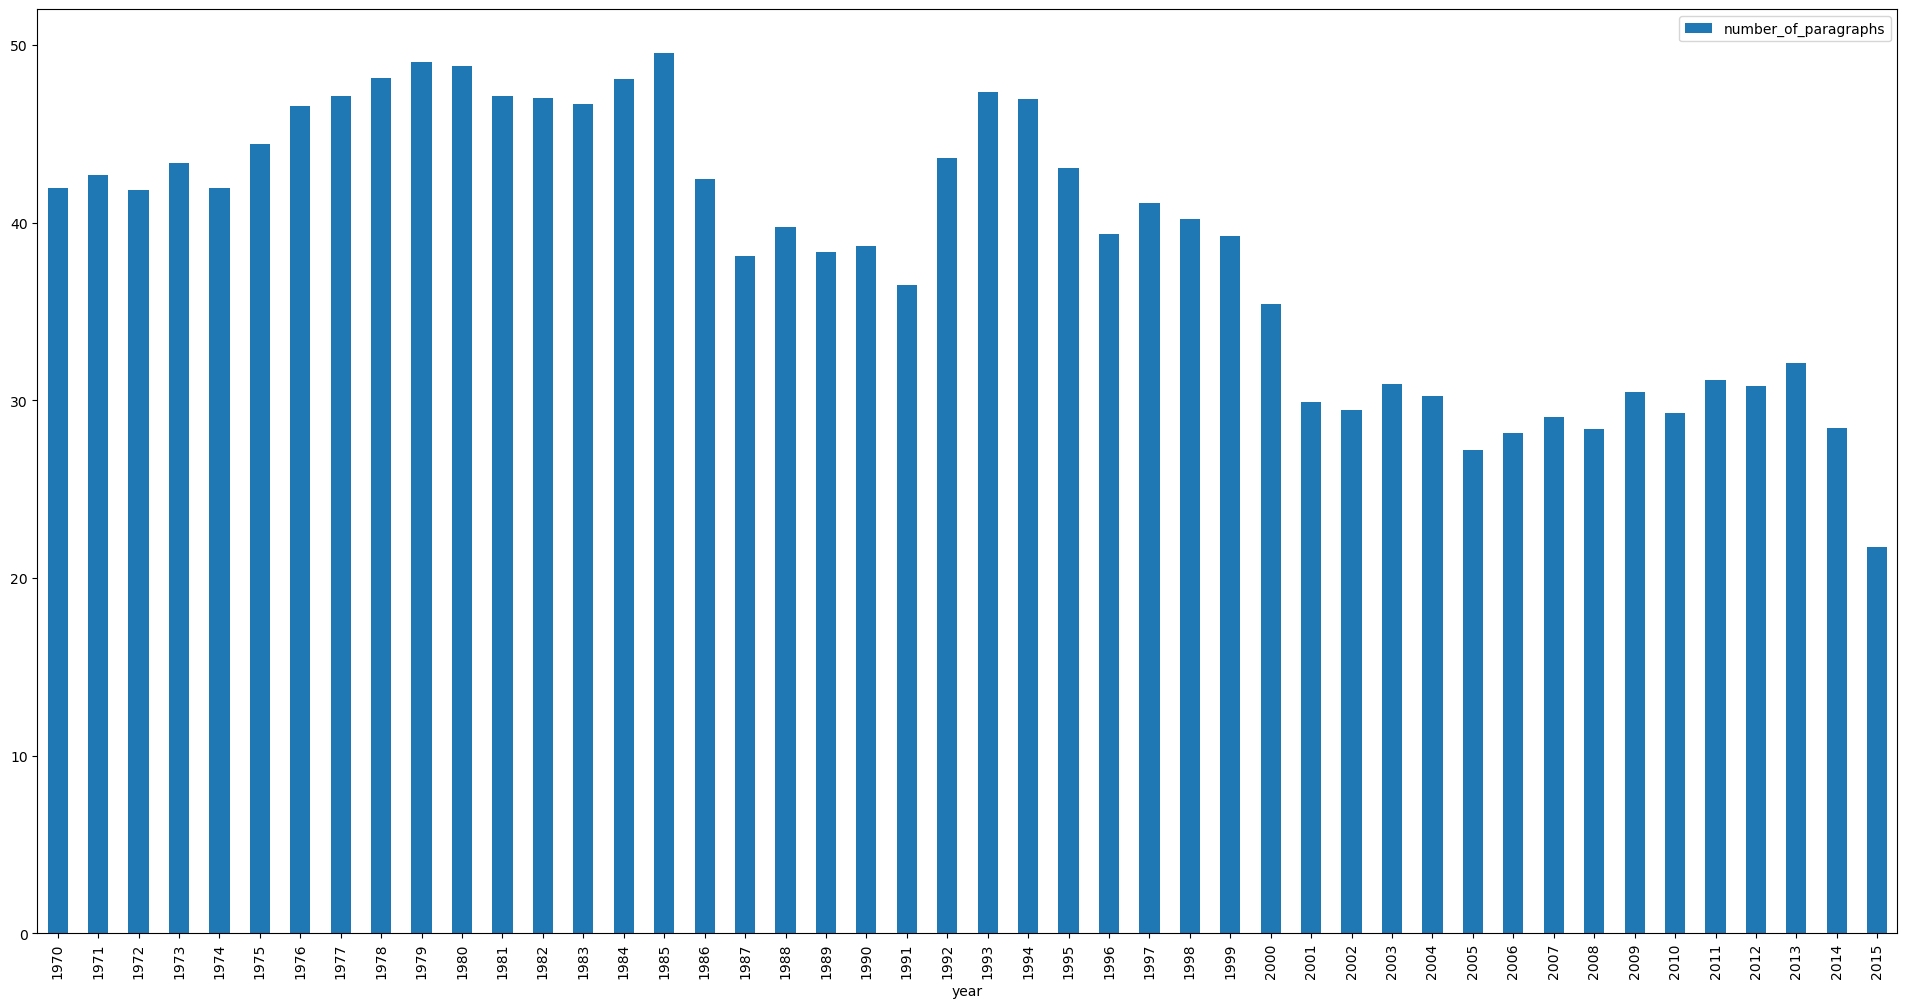

In [22]:
%matplotlib inline
df.groupby('year').agg({'number_of_paragraphs': 'mean'}).plot.bar(figsize=(24,12))

# Preparación de datos

Vectorización TFIDF

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [42]:
tfidf_text_vectorizer = TfidfVectorizer(min_df=5, max_df=0.7, stop_words='english')
tfidf_text_vectors = tfidf_text_vectorizer.fit_transform(df['text'])
tfidf_text_vectors.shape

(7507, 24604)

In [43]:
from sklearn.decomposition import NMF

nmf_text_model = NMF(n_components=10, random_state=42)
W_text_matrix = nmf_text_model.fit_transform(tfidf_text_vectors)
H_text_matrix = nmf_text_model.components_

In [44]:
def display_topics(model, features, no_top_word=5):
    for topic, words in enumerate(model.components_):
        total = words.sum()
        largest = words.argsort()[::-1]
        print("\nTopic %02d" % topic)
        for i in range(0, no_top_word):
            print(" %s (%2.2f)" % (features[largest[i]], abs(words[largest[i]]*100.0/total)))


In [45]:
display_topics(nmf_text_model, tfidf_text_vectorizer.get_feature_names_out())


Topic 00
 nuclear (1.04)
 weapons (0.55)
 disarmament (0.53)
 operation (0.39)
 treaty (0.36)

Topic 01
 terrorism (0.36)
 challenges (0.31)
 cooperation (0.30)
 reform (0.29)
 sustainable (0.29)

Topic 02
 africa (0.90)
 south (0.60)
 african (0.56)
 namibia (0.37)
 delegation (0.30)

Topic 03
 arab (0.99)
 israel (0.86)
 palestinian (0.59)
 lebanon (0.54)
 israeli (0.53)

Topic 04
 american (0.27)
 latin (0.27)
 america (0.27)
 panama (0.17)
 bolivia (0.16)

Topic 05
 pacific (1.53)
 islands (1.25)
 island (0.87)
 solomon (0.86)
 fiji (0.70)

Topic 06
 republic (0.84)
 viet (0.72)
 nam (0.67)
 socialist (0.55)
 soviet (0.54)

Topic 07
 guinea (4.37)
 equatorial (1.79)
 bissau (1.55)
 papua (1.52)
 portugal (0.53)

Topic 08
 european (0.81)
 europe (0.57)
 turkey (0.55)
 cyprus (0.51)
 greece (0.43)

Topic 09
 caribbean (0.93)
 small (0.62)
 bahamas (0.60)
 saint (0.59)
 barbados (0.57)


# TFIDF párrafos

In [46]:
paragraph_df = pd.DataFrame(
    [{"text": paragraph, "year": year}
    for paragraphs, year in zip(df["paragraphs"], df["year"])
        for paragraph in paragraphs if paragraph 
    ]
)

In [47]:
paragraph_df

,text,year
0,33: May I first convey to our President the co...,1970
1,35.\tThe utilization of the United Nations to ...,1970
2,36.\tThe whole of progressive mankind recalls ...,1970
3,37.\tAll this has had well known consequences ...,1970
4,38.\tOne of the undeniable proofs that the Uni...,1970
...,...,...
279071,"For some months now, we have watched heartbrea...",2015
279072,This tragic situation could have been avoided ...,2015
279073,"My country, Zimbabwe, is committed to a fair, ...",2015
279074,We invite other countries with which we may ha...,2015


In [48]:
tfidf_para_vectorizer = TfidfVectorizer(min_df=5, max_df=0.7, stop_words='english')
tfidf_para_vectors = tfidf_para_vectorizer.fit_transform(paragraph_df["text"])


In [49]:
nmf_para_model = NMF(n_components=10, random_state=42)
W_para_matrix = nmf_para_model.fit_transform(tfidf_para_vectors)
H_para_matrix = nmf_para_model.components_

In [50]:
display_topics(nmf_para_model, tfidf_para_vectorizer.get_feature_names_out())


Topic 00
 international (2.01)
 world (1.50)
 community (0.91)
 new (0.76)
 peace (0.67)

Topic 01
 general (2.88)
 session (2.85)
 assembly (2.83)
 mr (2.00)
 president (1.83)

Topic 02
 countries (4.41)
 developing (2.49)
 economic (1.51)
 developed (1.35)
 trade (0.92)

Topic 03
 nations (5.61)
 united (5.50)
 organization (1.27)
 states (1.03)
 charter (0.93)

Topic 04
 nuclear (4.91)
 weapons (3.25)
 disarmament (2.01)
 treaty (1.70)
 proliferation (1.45)

Topic 05
 rights (6.51)
 human (6.20)
 respect (1.16)
 fundamental (0.86)
 universal (0.83)

Topic 06
 africa (3.80)
 south (3.30)
 african (1.70)
 namibia (1.38)
 apartheid (1.18)

Topic 07
 security (6.08)
 council (5.82)
 permanent (1.48)
 reform (1.47)
 peace (1.31)

Topic 08
 people (1.35)
 peace (1.32)
 east (1.28)
 middle (1.17)
 palestinian (1.15)

Topic 09
 development (4.51)
 sustainable (1.20)
 economic (1.07)
 social (1.00)
 goals (0.94)


# SVD Singular Value Decomposition




In [51]:
from sklearn.decomposition import TruncatedSVD

In [54]:
svd_model = TruncatedSVD(n_components=10, random_state=42)
W_svd_para_matrix = svd_model.fit_transform(tfidf_para_vectors)
H_svd_para_matrix = svd_model.components_

In [55]:
display_topics(svd_model, tfidf_para_vectorizer.get_feature_names_out())


Topic 00
 nations (0.67)
 united (0.65)
 international (0.57)
 peace (0.46)
 world (0.46)

Topic 01
 general (13.54)
 assembly (12.65)
 session (12.55)
 mr (9.72)
 president (8.33)

Topic 02
 countries (20.15)
 development (15.63)
 economic (14.65)
 developing (13.74)
 session (10.42)

Topic 03
 nations (4.44)
 united (4.09)
 development (0.93)
 organization (0.85)
 charter (0.81)

Topic 04
 nuclear (22.52)
 weapons (14.90)
 disarmament (9.59)
 treaty (7.73)
 proliferation (6.75)

Topic 05
 rights (29.42)
 human (28.66)
 nuclear (8.94)
 weapons (6.23)
 respect (5.00)

Topic 06
 africa (8.90)
 south (8.25)
 united (3.89)
 african (3.84)
 namibia (3.51)

Topic 07
 council (13.48)
 security (12.35)
 africa (7.39)
 south (5.41)
 reform (3.49)

Topic 08
 countries (42.31)
 developing (25.29)
 council (21.70)
 rights (19.93)
 palestinian (16.26)

Topic 09
 development (40.08)
 sustainable (13.16)
 peace (10.26)
 goals (9.67)
 agenda (8.58)


# LDA Latient Dirichlet Allocation 

In [56]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english', min_df=5, max_df=0.7)
cv_vectors = cv.fit_transform(paragraph_df['text'])

In [57]:
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
W_lda_para_matrix = lda_model.fit_transform(cv_vectors)
H_lda_para_matrix = lda_model.components_

In [58]:
display_topics(lda_model, cv.get_feature_names_out())


Topic 00
 terrorism (1.26)
 international (1.19)
 world (1.02)
 people (0.98)
 war (0.77)

Topic 01
 countries (4.74)
 economic (2.54)
 developing (2.12)
 development (1.56)
 world (1.37)

Topic 02
 nuclear (2.71)
 weapons (2.00)
 states (1.61)
 disarmament (1.57)
 arms (1.22)

Topic 03
 government (1.88)
 country (1.21)
 peace (0.82)
 national (0.82)
 process (0.80)

Topic 04
 nations (5.69)
 united (5.30)
 rights (1.81)
 security (1.73)
 human (1.68)

Topic 05
 people (1.46)
 peace (1.25)
 africa (1.15)
 south (1.14)
 east (0.97)

Topic 06
 development (2.84)
 international (1.83)
 nations (1.40)
 united (1.27)
 cooperation (1.01)

Topic 07
 united (2.72)
 nations (2.65)
 republic (1.76)
 people (1.58)
 general (1.49)

Topic 08
 assembly (5.42)
 general (5.36)
 session (5.16)
 president (2.78)
 mr (2.77)

Topic 09
 world (2.31)
 peace (1.11)
 international (1.10)
 new (0.98)
 economic (0.91)


In [60]:
import pyLDAvis.sklearn

ModuleNotFoundError: No module named 'pyLDAvis.sklearn'